In [2]:
from lammps import lammps

In [3]:
l = lammps()

LAMMPS (29 Aug 2024)


In [13]:
# 0) Environment & file sanity checks
import os, sys, shutil, re
from pathlib import Path

BASE_DIR = Path('.')  # change if your inputs live elsewhere
INPUT = BASE_DIR / 'in.reax_cho_gasmix.lmp'
MOL_CH4 = BASE_DIR / 'mol.ch4'
MOL_O2  = BASE_DIR / 'mol.o2'

print('Working dir:', BASE_DIR.resolve())
for fp in [INPUT, MOL_CH4, MOL_O2]:
    print(f'  - {fp.name}:', 'OK' if fp.exists() else 'MISSING')
assert INPUT.exists(), 'Missing in.reax_cho_gasmix.lmp'
assert MOL_CH4.exists(), 'Missing mol.ch4'
assert MOL_O2.exists(), 'Missing mol.o2'

try:
    from lammps import lammps
    print('LAMMPS Python module: OK')
except Exception as e:
    raise SystemExit('LAMMPS Python module not found. Install a build with REAXFF+PYTHON.')

# Ensure output folders exist
for d in ['dumps','restarts']:
    (BASE_DIR / d).mkdir(exist_ok=True)
print('Output folders ready.')


Working dir: /Users/alirezas
  - in.reax_cho_gasmix.lmp: OK
  - mol.ch4: OK
  - mol.o2: OK
LAMMPS Python module: OK
Output folders ready.


In [29]:
# 1) Run LAMMPS via Python API using your input script
from lammps import lammps
import time

logfile = str(BASE_DIR / 'log.lammps')
print('Starting LAMMPS, logging to', logfile)

# You can pass cmdargs to control logging and processors
lmp = lammps(cmdargs=["-log", logfile])
tic = time.time()
lmp.file(str(INPUT))  # executes your script exactly as CLI would
toc = time.time()
print(f'LAMMPS run finished in {(toc - tic):.1f} s')

# Close if you won't call it again
lmp.close()


Starting LAMMPS, logging to log.lammps
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task
Created orthogonal box = (0 0 0) to (60 60 60)
  1 by 1 by 1 MPI processor grid
ERROR: Invalid bond type in Bonds section of molecule file: 2 1 3 2 (src/molecule.cpp:1087)
Last command: molecule        ch4 mol.ch4
LAMMPS (29 Aug 2024)


Exception: ERROR on proc 0: Unexpected line in molecule file while skipping Coords section:
Types
 (src/molecu

In [30]:
import os, pathlib, textwrap
print("CWD:", os.getcwd())
print("mol.ch4 exists?", pathlib.Path("mol.ch4").exists())
print("mol.o2  exists?", pathlib.Path("mol.o2").exists())


CWD: /Users/alirezas
mol.ch4 exists? True
mol.o2  exists? True


In [39]:
!lmp -in test.lmp

LAMMPS (29 Aug 2024)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task
Created orthogonal box = (0 0 0) to (20 20 20)
  1 by 1 by 1 MPI processor grid
ERROR: No atoms or invalid atom count in molecule file (src/molecule.cpp:522)
Last command: molecule   ch4 ${CH4file}


In [32]:
!dos2unix mol.ch4 mol.o2

zsh:1: command not found: dos2unix


In [41]:
# Create a robust fallback that avoids 'molecule' files entirely:
# We generate a LAMMPS DATA file (atom_style charge) with a random gas mixture
# of CH4 and O2 placed in a cubic box. Then we provide an input script that uses
# 'read_data' to run ReaxFF on this system. This bypasses the finicky 'molecule' parser.
#
# Files created:
#  - /mnt/data/data.gasmix_cho.lmp   (LAMMPS data file)
#  - /mnt/data/in.reax_cho_from_data.lmp  (input script that reads the data file)
#
import numpy as np

# Parameters
L = 60.0  # box size Å
n_CH4 = 120
n_O2 = 240

# Atomic types: 1=C, 2=H, 3=O
mass_C = 12.011
mass_H = 1.00784
mass_O = 15.999

# Molecule geometries (Å) in local coords
# CH4: C at origin, H at tetrahedral positions with C-H ~ 1.09 Å
a = 1.09 / np.sqrt(3.0)
ch4_local = np.array([
    [0.0, 0.0, 0.0],             # C
    [ a,  a,  a],                # H
    [-a, -a,  a],                # H
    [-a,  a, -a],                # H
    [ a, -a, -a],                # H
])
ch4_types = [1, 2, 2, 2, 2]

# O2: two O atoms at +/- 0.605 Å (bond length ~1.21 Å)
o2_local = np.array([
    [-0.605, 0.0, 0.0],
    [ 0.605, 0.0, 0.0],
])
o2_types = [3, 3]

# Random placement with simple overlap avoidance using bounding radii
rng = np.random.default_rng(7)
centers = []
species = []   # 'CH4' or 'O2'
orients = []   # random unit quaternions / rotation matrices
radii = []     # bounding sphere radius
mol_ids = []

def rand_rot():
    # Random rotation matrix via quaternion (uniform on SO(3))
    u1, u2, u3 = rng.random(), rng.random(), rng.random()
    q1 = np.sqrt(1-u1) * np.sin(2*np.pi*u2)
    q2 = np.sqrt(1-u1) * np.cos(2*np.pi*u2)
    q3 = np.sqrt(u1)   * np.sin(2*np.pi*u3)
    q4 = np.sqrt(u1)   * np.cos(2*np.pi*u3)
    q = np.array([q1,q2,q3,q4])
    w,x,y,z = q4,q1,q2,q3
    R = np.array([
        [1-2*(y*y+z*z), 2*(x*y - z*w), 2*(x*z + y*w)],
        [2*(x*y + z*w), 1-2*(x*x+z*z), 2*(y*z - x*w)],
        [2*(x*z - y*w), 2*(y*z + x*w), 1-2*(x*x+y*y)],
    ])
    return R

# radii (rough): CH4 ~ 2.0 Å, O2 ~ 1.2 Å (bounding spheres)
R_CH4 = 2.0
R_O2  = 1.2

def try_place(ntries=10000):
    placed = 0
    # target counts
    target = [('CH4', n_CH4, R_CH4), ('O2', n_O2, R_O2)]
    for specie, count, rad in target:
        for _ in range(count):
            ok = False
            for _ in range(ntries):
                c = rng.uniform(5.0, L-5.0, size=3)  # margin from walls
                # minimal distance to previous spheres
                if centers:
                    d2 = np.sum((np.array(centers) - c)**2, axis=1)
                    min_d = np.sqrt(d2.min())
                    if min_d < (rad + np.array(radii)).min():
                        # quick check is too strict; do pairwise check
                        pass
                # full check
                collided = False
                for (c0, r0) in zip(centers, radii):
                    if np.linalg.norm(c - c0) < (rad + r0 + 0.5):
                        collided = True
                        break
                if collided:
                    continue
                ok = True
                centers.append(c)
                species.append(specie)
                radii.append(rad)
                orients.append(rand_rot())
                break
            if not ok:
                raise RuntimeError(f"Failed to pack {specie}; increase box L or reduce counts.")
    return

try_place()

# Build atom list
atoms = []  # tuples: (id, molid, type, charge, x,y,z)
aid = 0
mid = 0
for c, sp, R in zip(centers, species, radii):
    mid += 1
    if sp == 'CH4':
        Rm = orients[mid-1]
        for p, t in zip(ch4_local, ch4_types):
            aid += 1
            pos = c + Rm @ p
            atoms.append((aid, mid, t, 0.0, pos[0], pos[1], pos[2]))
    else:
        Rm = orients[mid-1]
        for p, t in zip(o2_local, o2_types):
            aid += 1
            pos = c + Rm @ p
            atoms.append((aid, mid, t, 0.0, pos[0], pos[1], pos[2]))

natoms = len(atoms)
ntypes = 3

# Write data file
data_path = "./data.gasmix_cho.lmp"
with open(data_path, "w") as f:
    f.write("LAMMPS data file for CH4+O2 gas (atom_style charge)\n\n")
    f.write(f"{natoms} atoms\n")
    f.write(f"0 bonds\n0 angles\n0 dihedrals\n0 impropers\n\n")
    f.write(f"0  {L:.6f} xlo xhi\n")
    f.write(f"0  {L:.6f} ylo yhi\n")
    f.write(f"0  {L:.6f} zlo zhi\n\n")
    f.write("Masses\n\n")
    f.write("1 %.6f\n" % mass_C)
    f.write("2 %.6f\n" % mass_H)
    f.write("3 %.6f\n" % mass_O)
    f.write("\nAtoms # charge\n\n")
    for (aid, mid, t, q, x,y,z) in atoms:
        f.write(f"{aid} {mid} {t} {q:.6f} {x:.6f} {y:.6f} {z:.6f}\n")

# Write input script that reads the data file
in_path = "./in.reax_cho_from_data.lmp"
with open(in_path, "w") as f:
    f.write("""# CH4 + O2 gas from DATA file (ReaxFF-CHO)\n""")
    f.write("units           real\n")
    f.write("atom_style      charge\n")
    f.write("boundary        p p p\n\n")
    f.write(f"read_data       {data_path}\n\n")
    f.write("pair_style      reaxff NULL\n")
    f.write("pair_coeff      * * ffield.reax.cho C H O\n")
    f.write("special_bonds   reax/c\n\n")
    f.write("neighbor        2.0 bin\n")
    f.write("neigh_modify    every 1 delay 0 check yes\n\n")
    f.write("fix             qeq all qeq/reax 1 10.0 1.0e-6 200\n\n")
    f.write("velocity        all create 1500.0 492783 mom yes rot yes dist gaussian\n")
    f.write("fix             int all nve\n")
    f.write("fix             lang all langevin 1500.0 1500.0 100.0 90421\n\n")
    f.write("timestep        0.1\n")
    f.write("thermo_style    custom step temp press pe ke etotal\n")
    f.write("thermo          500\n\n")
    f.write("dump            xyz all custom 10000 dumps/xyz.*.gz id type q x y z\n")
    f.write("dump_modify     xyz sort id\n")
    f.write("restart         50000 restarts/reaxff.*.rst\n\n")
    f.write("run             50000\n")
    f.write("run             500000\n")

(data_path, in_path)


('./data.gasmix_cho.lmp', './in.reax_cho_from_data.lmp')

In [37]:
def inspect(path):
    with open(path,'rb') as f:
        raw=f.read()
    print(path, "size", len(raw), "bytes; last 16 bytes:", raw[-16:])
    print("--- printable dump ---")
    for i,line in enumerate(raw.split(b"\n"),1):
        print(f"{i:02d}:", repr(line))
inspect("mol.ch4")
inspect("mol.o2")


mol.ch4 size 301 bytes; last 16 bytes: b'0.0\n4 0.0\n5 0.0\n'
--- printable dump ---
01: b'# methane (atom_style charge)'
02: b'5 atoms'
03: b'0 bonds'
04: b'0 angles'
05: b'0 dihedrals'
06: b'0 impropers'
07: b'Coords'
08: b'1 0.000000 0.000000 0.000000'
09: b'2 0.629118 0.629118 0.629118'
10: b'3 -0.629118 -0.629118 0.629118'
11: b'4 -0.629118 0.629118 -0.629118'
12: b'5 0.629118 -0.629118 -0.629118'
13: b'Types'
14: b'1 1'
15: b'2 2'
16: b'3 2'
17: b'4 2'
18: b'5 2'
19: b'Charges'
20: b'1 0.0'
21: b'2 0.0'
22: b'3 0.0'
23: b'4 0.0'
24: b'5 0.0'
25: b''
mol.o2 size 161 bytes; last 16 bytes: b'ges\n1 0.0\n2 0.0\n'
--- printable dump ---
01: b'# oxygen (atom_style charge)'
02: b'2 atoms'
03: b'0 bonds'
04: b'0 angles'
05: b'0 dihedrals'
06: b'0 impropers'
07: b'Coords'
08: b'1 -0.605 0.000 0.000'
09: b'2  0.605 0.000 0.000'
10: b'Types'
11: b'1 3'
12: b'2 3'
13: b'Charges'
14: b'1 0.0'
15: b'2 0.0'
16: b''


In [42]:
!mkdir -p dumps restarts
!lmp -in in.reax_cho_from_data.lmp

LAMMPS (29 Aug 2024)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task
Reading data file ...
  orthogonal box = (0 0 0) to (60 60 60)
  1 by 1 by 1 MPI processor grid
ERROR: Unexpected end of data file (src/read_data.cpp:2102)
Last command: read_data       ./data.gasmix_cho.lmp


In [68]:
!mkdir -p dumps restarts
!lmp -in in.reax_cho_from_data_v3.lmp

LAMMPS (29 Aug 2024)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task
Reading data file ...
  orthogonal box = (0 0 0) to (60 60 60)
  1 by 1 by 1 MPI processor grid
  reading atoms ...
  1080 atoms
  read_data CPU = 0.004 seconds
Reading potential file ./ffield.reax.cho with DATE: 2010-02-19

CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE

Your simulation uses code contributions which should be cited:
- Type Label Framework: https://doi.org/10.1021/acs.jpcb.3c08419
- pair reaxff command: doi:10.1016/j.parco.2011.08.005
- fix qeq/reaxff command: doi:10.1016/j.parco.2011.08.005
The log file lists these citations in BibTeX format.

CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE

Neighbor list info ...
  update: every = 1 steps, delay = 0 steps, check = yes
  max neighbors/atom: 2000, page size: 100000
  master list distance cutoff = 12
  ghost atom cutoff = 12
  binsize = 6, bins 

In [52]:
!file -i ffield.reax.cho

ffield.reax.cho: regular file


In [56]:
!tail -c +4 ffield.reax.cho > ffield_clean.cho

In [1]:
# etl_reaxff.py
# Equal Thermodynamic-Length (ETL) control for ReaxFF (LAMMPS python interface)
# - Variable timestep from ETL budget
# - QEq tolerance chosen to keep solver-induced info-length ≤ α·Δℓ^2
# - Neighbor rebuild/skin pacing from displacement/ETL
# - Optional calibration sentinel to learn tol→force-error map
#
# Units assumed: 'real' (LAMMPS) so time is fs, k_B = 0.0019872041 kcal/mol-K
# If using 'metal' or 'si', update kB and unit conversions accordingly.

from __future__ import annotations
import math, time, numpy as np
from dataclasses import dataclass
from typing import Optional, Tuple, Dict

try:
    from lammps import lammps  # pip install lammps (or provided with your LAMMPS build)
except Exception as e:
    raise RuntimeError("LAMMPS Python module not found. Build LAMMPS with Python and reaxff.") from e

kB = 0.0019872041  # kcal/mol-K in 'real' units

@dataclass
class ETLConfig:
    T_target: float              # K (thermostat target)
    Delta_l: float = 0.05        # target ETL per step (dimensionless)
    dt_min: float = 0.02         # fs
    dt_max: float = 0.50         # fs
    dt_growth: float = 1.25      # per-step dt increase limit
    dt_shrink: float = 1.25      # per-step dt decrease limit
    alpha_qeq: float = 0.30      # fraction of ETL budget for QEq
    beta_neigh: float = 0.10     # fraction for neighbor errors (heuristic)
    qeq_nevery: int = 1          # QEq frequency (steps)
    qeq_cutoff: float = 10.0     # Å (example; match your system)
    qeq_maxiter: int = 200       # max CG iterations
    qeq_tol_loose: float = 1e-4  # starting/typical tolerance
    qeq_tol_tight: float = 1e-6  # used in calibration sentinel
    cal_every: int = 500         # run sentinel every N steps (0 disables)
    skin_base: float = 2.0       # Å base neighbor skin
    skin_max: float = 4.0        # Å cap
    log_every: int = 100         # print status every N steps

class ETLReaxController:
    def __init__(self, lmp: lammps, cfg: ETLConfig, qeq_fix_id: str = "qeq"):
        self.lmp = lmp
        self.cfg = cfg
        self.qeq_fix_id = qeq_fix_id
        self.step_count = 0
        self.dt_prev = cfg.dt_min
        self.last_rebuild_positions = None
        # Learned mapping: tol -> Σ||δF||^2/m  (simple exponential model updated by sentinel)
        self._tol_model = {"A": None, "B": None}  # log-error ≈ A + B*log10(tol)

    # ---------- low-level extractors ----------
    def _forces(self) -> np.ndarray:
        # returns (N,3) forces in kcal/mol/Å
        f = self.lmp.extract_atom("f", 3)  # 3 = 2D array
        natoms = self.lmp.get_natoms()
        return np.array([[f[i][0], f[i][1], f[i][2]] for i in range(natoms)])

    def _masses(self) -> np.ndarray:
        # mass per atom (g/mol). Need per-type mass map:
        types = np.array(self.lmp.extract_atom("type", 0), dtype=int)
        ntypes = int(self.lmp.get_natoms() and np.max(types))
        # LAMMPS stores masses per type: group/style or extract from "mass" command table
        # Python API: extract "mass" by type via lmp.extract_atom? Not directly.
        # Safer: store masses in an equal-style variable vector in your input, then read here.
        # For demonstration, we fallback to type=1 mass=1.0 (override with your own hook).
        m = np.ones_like(types, dtype=float)
        return m

    def _positions(self) -> np.ndarray:
        x = self.lmp.extract_atom("x", 3)
        natoms = self.lmp.get_natoms()
        return np.array([[x[i][0], x[i][1], x[i][2]] for i in range(natoms)])

    # ---------- ETL core ----------
    def _force_quadratic_form(self, masses: np.ndarray) -> float:
        F = self._forces()
        Fi2_over_m = (F**2).sum(axis=1) / np.maximum(masses, 1e-12)
        return float(Fi2_over_m.sum())  # Σ ||F_i||^2 / m_i

    def _choose_dt(self, S: float) -> float:
        # Δt = Δℓ * sqrt( kB*T / Σ||F||^2/m )
        cfg = self.cfg
        if S <= 0.0:
            dt = cfg.dt_max
        else:
            dt = cfg.Delta_l * math.sqrt((kB * cfg.T_target) / S)
        # growth/shrink smoothing + bounds
        dt = max(min(dt, self.dt_prev * cfg.dt_growth), self.dt_prev / cfg.dt_shrink)
        dt = min(max(dt, cfg.dt_min), cfg.dt_max)
        return dt

    # ---------- QEq tolerance budgeting ----------
    def _estimate_qeq_force_error_sum(self, tol: float) -> Optional[float]:
        """Return Σ||δF||^2/m estimate at given tol using learned model (if any)."""
        A, B = self._tol_model["A"], self._tol_model["B"]
        if A is None or B is None:
            return None
        log10e = A + B * math.log10(tol)
        return 10.0 ** log10e

    def _calibrate_qeq(self) -> None:
        """Sentinel: measure force error between loose vs tight QEq without moving atoms."""
        cfg = self.cfg
        masses = self._masses()

        # 1) Ensure 'loose' is active, run 0 to get F_loose
        self._set_qeq_tol(cfg.qeq_tol_loose)
        self.lmp.command("run 0 post no pre no")
        F_loose = self._forces()

        # 2) Switch to 'tight', run 0, get F_tight
        self._set_qeq_tol(cfg.qeq_tol_tight)
        self.lmp.command("run 0 post no pre no")
        F_tight = self._forces()

        # 3) Restore 'loose'
        self._set_qeq_tol(cfg.qeq_tol_loose)
        self.lmp.command("run 0 post no pre no")

        # 4) Compute Σ||δF||^2/m for both tolerances (δF at loose vs tight≈0)
        dF = F_loose - F_tight
        Fi2_over_m = (dF**2).sum(axis=1) / np.maximum(masses, 1e-12)
        err_loose = float(Fi2_over_m.sum())

        # Update log-linear model on two points: (tol_loose, err_loose) and (tol_tight, ~0)
        # Use a small floor for tight error to avoid -inf
        e_tight = max(err_loose * 1e-3, 1e-20)
        x = np.array([math.log10(cfg.qeq_tol_loose), math.log10(cfg.qeq_tol_tight)])
        y = np.log10(np.array([err_loose, e_tight]))
        B = (y[0] - y[1]) / (x[0] - x[1])
        A = y[0] - B * x[0]
        self._tol_model.update(A=A, B=B)

    def _pick_qeq_tol_for_budget(self, dt: float, S_phys: float) -> float:
        """Choose tol s.t. (dt^2/(kB T)) * Σ||δF||^2/m ≤ α Δℓ^2."""
        cfg = self.cfg
        budget = cfg.alpha_qeq * (cfg.Delta_l ** 2)  # info-length share
        # Need Σ||δF||^2/m ≤ budget * (kB*T) / dt^2
        cap = budget * (kB * cfg.T_target) / max(dt ** 2, 1e-30)

        # If we have a model, invert it to get tol; else fallback to nominal value
        if self._tol_model["A"] is None:
            return cfg.qeq_tol_loose

        A, B = self._tol_model["A"], self._tol_model["B"]
        # log10(sum_err) = A + B*log10(tol)  ->  log10(tol) = (log10(cap) - A)/B
        log10_tol = (math.log10(max(cap, 1e-30)) - A) / B
        tol = 10.0 ** log10_tol
        # Keep within sane bounds
        tol = min(max(tol, cfg.qeq_tol_tight), cfg.qeq_tol_loose)
        return tol

    def _set_qeq_tol(self, tol: float) -> None:
        """Re-define the qeq fix with new tolerance (LAMMPS requires unfix/fix)."""
        cfg = self.cfg
        # Unfix if exists
        try:
            self.lmp.command(f"unfix {self.qeq_fix_id}")
        except:
            pass
        self.lmp.command(
            f"fix {self.qeq_fix_id} all qeq/reax {cfg.qeq_nevery} {cfg.qeq_cutoff} "
            f"{tol} {cfg.qeq_maxiter}"
        )

    # ---------- Neighbor pacing ----------
    def _maybe_rebuild_neighbors(self, dt: float) -> None:
        cfg = self.cfg
        x = self._positions()
        if self.last_rebuild_positions is None:
            self.last_rebuild_positions = x.copy()
            # set initial neighbor settings
            self.lmp.command(f"neighbor {cfg.skin_base} bin")
            self.lmp.command("neigh_modify delay 0 every 1 check yes")
            return

        disp = np.linalg.norm(x - self.last_rebuild_positions, axis=1).max()
        # Simple policy: grow skin with dt, rebuild if max disp exceeds 0.5*skin
        skin = min(cfg.skin_base * math.sqrt(1.0 + dt / cfg.dt_min), cfg.skin_max)
        self.lmp.command(f"neighbor {skin:.3f} bin")
        # Trigger rebuild if needed
        if disp > 0.5 * skin:
            self.lmp.command("neigh_modify delay 0 every 1 check yes")
            self.lmp.command("run 0 post no pre no")  # rebuild now
            self.last_rebuild_positions = self._positions()

    # ---------- One ETL step ----------
    def step(self) -> None:
        self.step_count += 1
        masses = self._masses()
        S = self._force_quadratic_form(masses)  # Σ||F||^2/m
        dt = self._choose_dt(S)

        # QEq tolerance from budget
        if self.cfg.cal_every and (self.step_count % self.cfg.cal_every == 1):
            self._calibrate_qeq()
        tol = self._pick_qeq_tol_for_budget(dt, S)
        self._set_qeq_tol(tol)

        # Neighbor pacing
        self._maybe_rebuild_neighbors(dt)

        # Apply timestep and integrate one step
        self.lmp.command(f"timestep {dt:.6f}")
        self.lmp.command("run 1 post no pre no")  # fastest single step
        self.dt_prev = dt

        # Lightweight logging
        if self.cfg.log_every and (self.step_count % self.cfg.log_every == 0):
            temp = self.lmp.get_thermo("temp")
            print(f"[ETL] step={self.step_count} dt={dt:.4f} fs  T≈{temp:.1f} K  qeq_tol={tol:.1e}")

    # ---------- Convenience multi-step ----------
    def run(self, nsteps: int) -> None:
        for _ in range(nsteps):
            self.step()


In [2]:
# etl_dt_only.py
# Variable-timestep controller (ETL-dt-only) for LAMMPS + ReaxFF (units real)
from __future__ import annotations
import math, numpy as np
from dataclasses import dataclass

kB = 0.0019872041  # kcal/mol-K

@dataclass
class ETLCfg:
    T_target: float          # thermostat target (K), used for scaling
    Delta_l: float = 0.05    # ETL per step (dimensionless)
    dt_min: float = 0.02     # fs
    dt_max: float = 0.50     # fs
    dt_growth: float = 1.25  # dt_{t+1} ≤ this * dt_t
    dt_shrink: float = 1.25  # dt_{t+1} ≥ dt_t / this
    log_every: int = 1000    # print progress every N ETL steps
    # Mass map for your system (type -> g/mol). C=1,H=2,O=3 for your data file
    mass_by_type: dict = None

class ETLTimestepOnly:
    def __init__(self, lmp, cfg: ETLCfg):
        self.lmp = lmp
        self.cfg = cfg
        self.step = 0
        self.dt_prev = cfg.dt_min
        if self.cfg.mass_by_type is None:
            # sensible default for CHO
            self.cfg.mass_by_type = {1: 12.011, 2: 1.00784, 3: 15.999}

    def _forces(self) -> np.ndarray:
        f = self.lmp.extract_atom("f", 3)  # 3 = 2D array
        n = self.lmp.get_natoms()
        return np.array([[f[i][0], f[i][1], f[i][2]] for i in range(n)], dtype=float)

    def _types(self) -> np.ndarray:
        t = self.lmp.extract_atom("type", 0)  # 0 = 1D array of ints
        n = self.lmp.get_natoms()
        return np.array([int(t[i]) for i in range(n)], dtype=int)

    def _masses(self) -> np.ndarray:
        types = self._types()
        return np.array([self.cfg.mass_by_type[int(t)] for t in types], dtype=float)

    def _sum_F2_over_m(self) -> float:
        F = self._forces()
        m = self._masses()
        # Σ ||F_i||^2 / m_i  (F in kcal/mol/Å, m in g/mol)
        return float(((F**2).sum(axis=1) / np.maximum(m, 1e-12)).sum())

    def _choose_dt(self, S: float) -> float:
        # Δt = Δℓ * sqrt( kB T / Σ||F||^2/m ), then smooth & clamp
        cfg = self.cfg
        if S <= 0.0:
            dt = cfg.dt_max
        else:
            dt = cfg.Delta_l * math.sqrt((kB * cfg.T_target) / S)
        dt = max(min(dt, self.dt_prev * cfg.dt_growth), self.dt_prev / cfg.dt_shrink)
        dt = min(max(dt, cfg.dt_min), cfg.dt_max)
        return dt

    def run_until(self, t_ps: float, dump_every_steps: int | None = None) -> dict:
        """
        Integrate until physical time 't_ps' (picoseconds) is reached,
        returning a log dict with per-step dt and cumulative time.
        """
        cum_time_fs = 0.0
        log = {"dt_fs": [], "cum_fs": []}
        while cum_time_fs < t_ps * 1000.0:
            S = self._sum_F2_over_m()
            dt = self._choose_dt(S)
            self.lmp.command(f"timestep {dt:.6f}")
            self.lmp.command("run 1 post no pre no")
            self.dt_prev = dt
            cum_time_fs += dt
            self.step += 1
            if self.cfg.log_every and (self.step % self.cfg.log_every == 0):
                T = self.lmp.get_thermo("temp")
                print(f"[ETL] step={self.step} dt={dt:.3f} fs  T≈{T:.1f} K  cum={cum_time_fs/1000:.3f} ps")
            log["dt_fs"].append(dt)
            log["cum_fs"].append(cum_time_fs)
        return log

In [12]:
# etl_dt_only.py  (ETL-dt only, fixed scaling & chunking)
from __future__ import annotations
import math, numpy as np
from dataclasses import dataclass

kB = 0.0019872041  # kcal/mol-K (LAMMPS 'real' units)

@dataclass
class ETLCfg:
    T_target: float            # K
    Delta_l: float = None      # ETL per step; if None we auto-calibrate from dt_target0
    dt_min: float = 0.02       # fs
    dt_max: float = 0.50       # fs
    dt_growth: float = 1.5     # allow faster growth so it can leave dt_min
    dt_shrink: float = 2.0
    log_every: int = 1000
    mass_by_type: dict | None = None
    # new:
    dt_target0: float = 0.10   # fs, used only for one-shot auto-calibration
    chunk: int = 10            # run this many steps per dt update (reduces overhead)

class ETLTimestepOnly:
    def __init__(self, lmp, cfg: ETLCfg):
        self.lmp = lmp
        self.cfg = cfg
        self.step = 0
        self.dt_prev = cfg.dt_min
        if self.cfg.mass_by_type is None:
            self.cfg.mass_by_type = {1:12.011, 2:1.00784, 3:15.999}
        # one-shot autocalibration of Delta_l to hit dt_target0 at current state
        if self.cfg.Delta_l is None:
            Sbar = self._Sbar_F2_over_m()  # per-DOF metric at the *current* forces
            # want dt0 = Delta_l * sqrt(kBT/Sbar) -> Delta_l = dt0 * sqrt(Sbar/(kBT))
            self.cfg.Delta_l = self.cfg.dt_target0 * math.sqrt(Sbar/(kB*self.cfg.T_target))
            # clamp so it won't suggest insane dt later
            self.cfg.Delta_l = max(1e-6, min(self.cfg.Delta_l, 5.0))

    # ---- extractors
    def _forces(self) -> np.ndarray:
        f = self.lmp.extract_atom("f", 3)
        n = self.lmp.get_natoms()
        return np.array([[f[i][0], f[i][1], f[i][2]] for i in range(n)], dtype=float)

    def _types(self) -> np.ndarray:
        t = self.lmp.extract_atom("type", 0)
        n = self.lmp.get_natoms()
        return np.array([int(t[i]) for i in range(n)], dtype=int)

    def _masses(self) -> np.ndarray:
        types = self._types()
        return np.array([self.cfg.mass_by_type[int(t)] for t in types], dtype=float)

    # ---- ETL metric (per DOF)
    def _Sbar_F2_over_m(self) -> float:
        """
        Return Sbar = (1/(3N)) * sum_i ||F_i||^2 / m_i  (per-DOF scaling)
        This removes the √N penalty on dt.
        """
        F = self._forces()
        m = self._masses()
        N = max(len(m), 1)
        Stot = float(((F**2).sum(axis=1) / np.maximum(m,1e-12)).sum())
        return Stot / (3.0 * N)

    def _choose_dt(self, Sbar: float) -> float:
        cfg = self.cfg
        if Sbar <= 0.0:
            dt = cfg.dt_max
        else:
            dt = cfg.Delta_l * math.sqrt((kB * cfg.T_target) / Sbar)
        # smooth & clamp
        dt = max(min(dt, self.dt_prev * cfg.dt_growth), self.dt_prev / cfg.dt_shrink)
        dt = min(max(dt, cfg.dt_min), cfg.dt_max)
        return dt

    def run_until(self, t_ps: float) -> dict:
        """
        Integrate until physical time 't_ps' (ps) using chunked updates.
        Returns {'dt_fs': list, 'cum_fs': list}.
        """
        cum_fs = 0.0
        log = {"dt_fs": [], "cum_fs": []}
        while cum_fs < t_ps * 1000.0:
            # compute dt from current forces
            Sbar = self._Sbar_F2_over_m()
            dt = self._choose_dt(Sbar)
            # choose how many steps we can take without overshooting target time
            remaining = max(0.0, t_ps*1000.0 - cum_fs)
            nsteps = int(min(self.cfg.chunk, math.ceil(remaining / max(dt,1e-12))))
            # integrate nsteps at this dt
            self.lmp.command(f"timestep {dt:.6f}")
            self.lmp.command(f"run {nsteps} post no pre no")
            self.dt_prev = dt
            self.step += nsteps
            cum_fs += nsteps * dt
            if self.cfg.log_every and (self.step % self.cfg.log_every == 0):
                T = self.lmp.get_thermo("temp")
                print(f"[ETL] step={self.step} dt={dt:.3f} fs  T≈{T:.1f} K  cum={cum_fs/1000:.3f} ps")
            log["dt_fs"].append(dt)
            log["cum_fs"].append(cum_fs)
        return log


In [5]:
# run_compare_dt_only.py
from lammps import lammps
# from etl_dt_only import ETLTimestepOnly, ETLCfg
import json, time, os

DATA = "./data.gasmix_cho_v3.lmp"     # your working data file
FF   = "./ffield.reax.cho"            # your working CHO file
T_TARGET = 1500.0                     # K
PHYS_TIME_PS = 5                   # compare to 50 ps of dynamics
SEED = 492783                         # keep seed fixed across both

def setup_common(lmp):
    lmp.command("units real")
    lmp.command("atom_style charge")
    lmp.command("boundary p p p")
    lmp.command(f"read_data {DATA}")
    lmp.command("pair_style      reaxff NULL")
    lmp.command(f"pair_coeff * * {FF} C H O")
    lmp.command("fix q all qeq/reaxff 1 0.0 10.0 1.0e-6 reaxff maxiter 200")
    lmp.command("neighbor 2.0 bin")
    lmp.command("neigh_modify every 1 delay 0 check yes")
    # Thermostat: same as your baseline
    lmp.command(f"velocity all create {T_TARGET} {SEED} mom yes rot yes dist gaussian")
    lmp.command("fix int all nve")
    lmp.command(f"fix lang all langevin {T_TARGET} {T_TARGET} 100.0 90421")
    lmp.command("thermo_style custom step temp press pe ke etotal")
    lmp.command("thermo 500")
    lmp.command("run 0")

# def write_restart(path):
#     lmp = lammps()
#     setup_common(lmp)
#     lmp.command(f"write_restart {path}")
#     lmp.close()

def write_restart(path):
    lmp = lammps()
    setup_common(lmp)              # your function
    lmp.command("timestep 0.10")   # safe & conservative
    lmp.command("thermo 1000")
    lmp.command("run 5000")        # 0.5 ps warm-up at 1500 K
    lmp.command(f"write_restart {path}")
    lmp.close()

def ensure_integrator_and_thermostat(lmp, T):
    # clear old ones if present
    for fx in ("int", "lang"):
        try: lmp.command(f"unfix {fx}")
        except: pass
    # re-apply same scheme as baseline
    lmp.command("fix int all nve")
    lmp.command(f"fix lang all langevin {T} {T} 100.0 90421")
    # neighbor settings (cheap + safe to reissue)
    lmp.command("neighbor 2.0 bin")
    lmp.command("neigh_modify every 1 delay 0 check yes")

def reinit_reaxff_after_restart(lmp, ffpath):
    # re-specify pair style & coeffs (reaxff keeps nothing in restart)
    lmp.command("pair_style      reaxff NULL")
    lmp.command(f"pair_coeff * * {ffpath} C H O")
    # (re)define QEq to match pair style
    try: lmp.command("unfix q")
    except: pass
    lmp.command("fix q all qeq/reaxff 1 0.0 10.0 1.0e-6 reaxff maxiter 200")

def run_fixed_dt(restart, dt_fs=0.1, t_ps=PHYS_TIME_PS, logpath="log_fixed.json"):
    steps = int(round((t_ps*1000.0)/dt_fs))
    lmp = lammps(cmdargs=["-log","log.fixed"])
    lmp.command(f"read_restart {restart}")
    reinit_reaxff_after_restart(lmp, FF)      # <-- NEW
    ensure_integrator_and_thermostat(lmp, T_TARGET)
    lmp.command("reset_timestep 0")

    # fresh dump (no 'undump all')
    lmp.command("dump dfix all custom 10000 dumps/fixed.*.gz id type q x y z")
    lmp.command("dump_modify dfix sort id")

    lmp.command(f"timestep {dt_fs}")
    import time, json
    t0=time.time(); lmp.command(f"run {steps} post no pre no"); t1=time.time()
    lmp.close()
    with open(logpath,"w") as f: json.dump({"steps":steps,"dt_fs":dt_fs,"wall_s":t1-t0}, f, indent=2)
    print(f"[fixed] ran {steps} steps @ {dt_fs} fs → ~{t_ps:.3f} ps; wall={t1-t0:.1f}s")

def run_etl_dt(restart, t_ps=PHYS_TIME_PS, logpath="log_etl.json"):
    # lmp = lammps(cmdargs=["-log","log.etl"])
    lmp = lammps(cmdargs=["-log","log.etl", "-screen","none"])
    lmp.command(f"read_restart {restart}")
    reinit_reaxff_after_restart(lmp, FF)      # <-- NEW
    ensure_integrator_and_thermostat(lmp, T_TARGET)
    lmp.command("reset_timestep 0")

    # fresh dump (no 'undump all')
    lmp.command("dump detl all custom 10000 dumps/etl.*.gz id type q x y z")
    lmp.command("dump_modify detl sort id")

    # from etl_dt_only import ETLTimestepOnly, ETLCfg
    ctl = ETLTimestepOnly(
        lmp,
        ETLCfg(T_target=T_TARGET,
               Delta_l=None,        # <-- let it auto-calibrate from dt_target0
               dt_target0=0.10,     # match your fixed-dt baseline
               dt_min=0.02, dt_max=0.50,
               dt_growth=1.5, dt_shrink=2.0,
               chunk=10,
               log_every=1000,
               mass_by_type={1:12.011, 2:1.00784, 3:15.999})
    )

    import time, json
    t0=time.time(); log = ctl.run_until(t_ps); t1=time.time()
    lmp.close()
    with open(logpath,"w") as f: json.dump({"etl":log,"wall_s":t1-t0}, f, indent=2)
    print(f"[ETL] reached {t_ps:.3f} ps in {len(log['dt_fs'])} ETL steps; wall={t1-t0:.1f}s")

def run_etl_dt_qeq(restart, t_ps=PHYS_TIME_PS, logpath="log_etl_qeq.json"):
    # from etl_dt_qeq import ETLTimestepQEq, ETLCfgQEq
    # silence screen (keeps memory calm); keep separate log file
    lmp = lammps(cmdargs=["-log","log.etlqeq", "-screen","none"])
    lmp.command(f"read_restart {restart}")
    reinit_reaxff_after_restart(lmp, FF)
    ensure_integrator_and_thermostat(lmp, T_TARGET)
    lmp.command("reset_timestep 0")
    lmp.command("thermo 100000000")
    lmp.command("thermo_style custom step temp pe ke etotal press")
    # sparse dump (optional)
    lmp.command("dump detl all custom 100000 dumps/etlqeq.*.gz id type q x y z")
    lmp.command("dump_modify detl sort id")

    # when you construct ETLCfgQEq for ETL+QEq
    ctl = ETLTimestepQEq(
        lmp,
        ETLCfgQEq(
            T_target=T_TARGET,
            Delta_l=None,          # let auto-cal compute it
            dt_target0=0.30,       # << was 0.10; 3× larger gain -> dt ≈ 3×
            dt_min=0.03, dt_max=0.30,
            dt_growth=1.5, dt_shrink=2.0,
            chunk=20,              # cut overhead further
            log_every=1000,
            mass_by_type={1:12.011,2:1.00784,3:15.999},
            # QEq knobs – fine to leave tol_max=5e-4 since forces aren’t sensitive
            qeq_fix_id="q", qeq_nevery=1, qeq_cutlo=0.0, qeq_cuthi=10.0, qeq_maxiter=200,
            tol_min=1e-6, tol_max=5e-4, alpha_qeq=0.30, cal_every=100, tol_hysteresis=2.0
    ))

    import time, json
    t0=time.time(); log = ctl.run_until(t_ps); t1=time.time()
    lmp.close()
    with open(logpath,"w") as f: json.dump({"etl_qeq":log,"wall_s":t1-t0}, f, indent=2)
    print(f"[ETL+QEq] reached {t_ps:.3f} ps in {len(log['dt_fs'])} chunks; wall={t1-t0:.1f}s")

if __name__ == "__main__":
    os.makedirs("dumps", exist_ok=True); os.makedirs("restarts", exist_ok=True)
    rst = "restarts/start.rst"
    if not os.path.exists(rst):
        write_restart(rst)
    # run_fixed_dt(rst, dt_fs=0.1, t_ps=PHYS_TIME_PS, logpath="log_fixed.json")
    # run_etl_dt(rst, t_ps=PHYS_TIME_PS, logpath="log_etl.json")
    # e.g., quick 0.5 ps
    run_etl_dt_qeq(rst, t_ps=0.5, logpath="log_etl_qeq.json")


LAMMPS (29 Aug 2024)
[ETL+QEq] step=1000 dt=0.030 fs tol~5.0e-04 T≈1509.5K cum=0.030ps
[ETL+QEq] step=2000 dt=0.030 fs tol~5.0e-04 T≈1513.3K cum=0.060ps
[ETL+QEq] step=3000 dt=0.030 fs tol~5.0e-04 T≈1449.2K cum=0.090ps
[ETL+QEq] step=4000 dt=0.030 fs tol~5.0e-04 T≈1512.9K cum=0.120ps
[ETL+QEq] step=5000 dt=0.030 fs tol~5.0e-04 T≈1526.9K cum=0.150ps
[ETL+QEq] step=6000 dt=0.030 fs tol~5.0e-04 T≈1515.4K cum=0.180ps
[ETL+QEq] step=7000 dt=0.030 fs tol~5.0e-04 T≈1560.3K cum=0.210ps
[ETL+QEq] step=8000 dt=0.030 fs tol~5.0e-04 T≈1520.4K cum=0.240ps
[ETL+QEq] step=9000 dt=0.030 fs tol~5.0e-04 T≈1509.0K cum=0.270ps
[ETL+QEq] step=10000 dt=0.030 fs tol~5.0e-04 T≈1530.0K cum=0.300ps
[ETL+QEq] step=11000 dt=0.030 fs tol~5.0e-04 T≈1544.5K cum=0.330ps
[ETL+QEq] step=12000 dt=0.030 fs tol~5.0e-04 T≈1530.0K cum=0.360ps
[ETL+QEq] step=13000 dt=0.030 fs tol~5.0e-04 T≈1465.1K cum=0.390ps
[ETL+QEq] step=14000 dt=0.030 fs tol~5.0e-04 T≈1496.9K cum=0.420ps
[ETL+QEq] step=15000 dt=0.030 fs tol~5.0e-04 T≈154

In [4]:
import json, gzip, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

def parse_log_table(path="log.lammps"):
    cols=None; rows=[]
    for line in open(path,'r',errors='ignore'):
        s=line.strip()
        if s.startswith("Step "): cols=s.split(); rows=[]; continue
        if cols and (s.startswith("Loop time of") or s.startswith("Minimization stats") or s.startswith("Per MPI")):
            break
        if cols:
            parts=s.split()
            if len(parts)==len(cols):
                try: rows.append([float(x) for x in parts])
                except: pass
    return pd.DataFrame(rows, columns=cols) if rows else pd.DataFrame()

def load_dump_atoms(fname):
    # reads last frame from a LAMMPS custom dump (id type q x y z)
    with gzip.open(fname,'rt') if str(fname).endswith(".gz") else open(fname,'r') as f:
        nat=None; box=None; ids=[]; ty=[]; pos=[]
        for line in f:
            if "ITEM: TIMESTEP" in line:
                # reset per-frame
                ids=[]; ty=[]; pos=[]
            elif line.startswith("ITEM: NUMBER OF ATOMS"):
                nat = int(next(f).strip())
            elif line.startswith("ITEM: BOX BOUNDS"):
                xlo,xhi = map(float, next(f).split()[:2])
                ylo,yhi = map(float, next(f).split()[:2])
                zlo,zhi = map(float, next(f).split()[:2])
                box = np.array([xhi-xlo, yhi-ylo, zhi-zlo])
            elif line.startswith("ITEM: ATOMS"):
                # columns: id type q x y z
                for _ in range(nat):
                    i,t,_,x,y,z = next(f).split()
                    ids.append(int(i)); ty.append(int(t)); pos.append([float(x),float(y),float(z)])
    order = np.argsort(ids)
    return np.array(ty)[order], np.array(pos)[order], box

def rdf(pos, types, selA, selB, box, rmax=6.0, dr=0.05):
    A = np.where(np.isin(types, selA))[0]
    B = np.where(np.isin(types, selB))[0]
    Lx,Ly,Lz = box
    edges = np.arange(0, rmax+dr, dr); hist = np.zeros_like(edges[:-1])
    for i in A:
        d = pos[B]-pos[i]
        d[:,0] -= np.rint(d[:,0]/Lx)*Lx
        d[:,1] -= np.rint(d[:,1]/Ly)*Ly
        d[:,2] -= np.rint(d[:,2]/Lz)*Lz
        r = np.linalg.norm(d, axis=1)
        h, _ = np.histogram(r, bins=edges)
        hist += h
    # Normalize to ideal gas
    rho = len(B)/(Lx*Ly*Lz)
    r = 0.5*(edges[1:]+edges[:-1])
    shell = 4*np.pi*r*r*dr
    g = hist/(len(A)*rho*shell + 1e-12)
    return r, g

# --- speed/thermo summary
df = parse_log_table("log.lammps")  # last run's log; run analyses separately for fixed vs etl
print(df.head())

with open("log_fixed.json") as f: fixed = json.load(f)
with open("log_etl.json") as f: etl = json.load(f)

print("Wall (fixed):", fixed["wall_s"], "s")
print("Wall (ETL):  ", etl["wall_s"], "s")
plt.figure(); plt.title("ETL dt distribution"); plt.hist(etl["etl"]["dt_fs"], bins=50); plt.xlabel("dt (fs)"); plt.ylabel("count"); plt.show()

# --- RDF example on final snapshots
ty_f,pos_f,box_f = load_dump_atoms(sorted(Path("dumps").glob("fixed.*.gz"))[-1])
ty_e,pos_e,box_e = load_dump_atoms(sorted(Path("dumps").glob("etl.*.gz"))[-1])
r,g_CO_f = rdf(pos_f, ty_f, selA=[1], selB=[3], box=box_f)  # C-O
r,g_CO_e = rdf(pos_e, ty_e, selA=[1], selB=[3], box=box_e)
plt.figure(); plt.plot(r,g_CO_f,label="fixed"); plt.plot(r,g_CO_e,label="ETL"); plt.xlabel("r (Å)"); plt.ylabel("g_CO(r)"); plt.legend(); plt.title("RDF C–O"); plt.show()

# --- simple chemistry proxies (OH and CO counts by cutoff)
def count_pairs(pos, types, a_types, b_types, rc, box):
    A = np.where(np.isin(types, a_types))[0]; B = np.where(np.isin(types, b_types))[0]
    Lx,Ly,Lz = box; cnt=0
    for i in A:
        d = pos[B]-pos[i]
        d[:,0] -= np.rint(d[:,0]/Lx)*Lx
        d[:,1] -= np.rint(d[:,1]/Ly)*Ly
        d[:,2] -= np.rint(d[:,2]/Lz)*Lz
        r = np.linalg.norm(d, axis=1)
        cnt += int((r < rc).sum())
    return cnt

oh_f = count_pairs(pos_f, ty_f, [3],[2], rc=1.2, box=box_f)
oh_e = count_pairs(pos_e, ty_e, [3],[2], rc=1.2, box=box_e)
co_f = count_pairs(pos_f, ty_f, [1],[3], rc=1.5, box=box_f)
co_e = count_pairs(pos_e, ty_e, [1],[3], rc=1.5, box=box_e)
print(f"OH proxies (fixed,ETL): {oh_f}, {oh_e}")
print(f"CO proxies (fixed,ETL): {co_f}, {co_e}")

FileNotFoundError: [Errno 2] No such file or directory: 'log.lammps'

In [3]:
# etl_dt_qeq.py  — ETL with adaptive QEq for LAMMPS pair_style reaxff (units 'real')
from __future__ import annotations
import math, numpy as np
from dataclasses import dataclass

kB = 0.0019872041  # kcal/mol-K

@dataclass
class ETLCfgQEq:
    # --- ETL (dt) core ---
    T_target: float
    Delta_l: float | None = None       # if None, auto-calibrated from dt_target0 at start
    dt_min: float = 0.02               # fs
    dt_max: float = 0.50               # fs
    dt_growth: float = 1.5
    dt_shrink: float = 2.0
    dt_target0: float = 0.10           # fs; only for the one-shot auto-cal
    chunk: int = 10                    # integrate this many steps per dt update
    log_every: int = 1000
    mass_by_type: dict | None = None   # {type: mass}; default CHO below

    # --- QEq adaptation (reaxff) ---
    qeq_fix_id: str = "q"
    qeq_nevery: int = 1
    qeq_cutlo: float = 0.0             # Å
    qeq_cuthi: float = 10.0            # Å
    qeq_maxiter: int = 200
    tol_min: float = 1e-6              # tightest (more accurate, slower)
    tol_max: float = 1e-4              # loosest (faster)
    alpha_qeq: float = 0.3             # fraction of ETL budget allowed to QEq error
    cal_every: int = 50                # recalibrate model every N chunks (0=never)
    tol_hysteresis: float = 1.5        # only re-issue fix if tol changes by this factor

class ETLTimestepQEq:
    """
    Variable dt via ETL + adaptive QEq tolerance for pair_style reaxff.
    - Per-DOF force metric (no sqrt(N) penalty).
    - Chunked runs to reduce LAMMPS call overhead.
    - QEq tolerance chosen to keep solver-induced info-length within alpha*Δℓ^2.
    - Tiny "sentinel" (run 0) learns log10(sum||δF||^2/m per DOF) vs log10(tol).
    """
    def __init__(self, lmp, cfg: ETLCfgQEq):
        self.lmp = lmp
        self.cfg = cfg
        self.step = 0
        self.dt_prev = cfg.dt_min
        if self.cfg.mass_by_type is None:
            self.cfg.mass_by_type = {1:12.011, 2:1.00784, 3:15.999}  # C,H,O
        # model: log10(err_bar) = A + B * log10(tol)
        self._A = None; self._B = None
        self._last_tol = None

        # Auto-calibrate Δℓ so the first dt ≈ dt_target0
        if self.cfg.Delta_l is None:
            Sbar = self._Sbar_F2_over_m()
            self.cfg.Delta_l = self.cfg.dt_target0 * math.sqrt(Sbar/(kB*self.cfg.T_target))
            self.cfg.Delta_l = max(1e-6, min(self.cfg.Delta_l, 5.0))

        # Ensure we start with a valid QEq fix at some tolerance
        self._ensure_qeq_fix(self.cfg.tol_min)
        # ensure forces are current before using them
        self.lmp.command("run 0 post no pre no")  

    # ----------- extractors -----------
    def _forces(self) -> np.ndarray:
        f = self.lmp.extract_atom("f", 3)
        n = self.lmp.get_natoms()
        return np.array([[f[i][0], f[i][1], f[i][2]] for i in range(n)], dtype=float)

    def _types(self) -> np.ndarray:
        t = self.lmp.extract_atom("type", 0)
        n = self.lmp.get_natoms()
        return np.array([int(t[i]) for i in range(n)], dtype=int)

    def _masses(self) -> np.ndarray:
        types = self._types()
        return np.array([self.cfg.mass_by_type[int(t)] for t in types], dtype=float)

    # ----------- ETL metric (per DOF) -----------
    def _Sbar_F2_over_m(self) -> float:
        F = self._forces()
        m = self._masses()
        N = max(len(m), 1)
        Stot = float(((F**2).sum(axis=1) / np.maximum(m,1e-12)).sum())
        return Stot / (3.0 * N)

    def _choose_dt(self, Sbar: float) -> float:
        cfg = self.cfg
        if Sbar <= 0.0:
            dt = cfg.dt_max
        else:
            dt = cfg.Delta_l * math.sqrt((kB * cfg.T_target) / Sbar)
        dt = max(min(dt, self.dt_prev * cfg.dt_growth), self.dt_prev / cfg.dt_shrink)
        dt = min(max(dt, cfg.dt_min), cfg.dt_max)
        return dt

    # ----------- QEq model & control -----------
    def _ensure_qeq_fix(self, tol: float):
        tol = min(max(tol, self.cfg.tol_min), self.cfg.tol_max)
        # Only (re)define if not set yet or tol changed enough
        if (self._last_tol is None) or (max(self._last_tol, tol)/max(min(self._last_tol, tol),1e-30) >= self.cfg.tol_hysteresis):
            try: self.lmp.command(f"unfix {self.cfg.qeq_fix_id}")
            except: pass
            self.lmp.command(
                f"fix {self.cfg.qeq_fix_id} all qeq/reaxff "
                f"{self.cfg.qeq_nevery} {self.cfg.qeq_cutlo} {self.cfg.qeq_cuthi} "
                f"{tol} reaxff maxiter {self.cfg.qeq_maxiter}"
            )
            self._last_tol = tol

    def _calibrate_model(self):
        """
        Learn A,B for log10(err_bar) ≈ A + B log10(tol) at the current geometry.
        If loose and tight give ~identical forces, skip modeling and run at tol_max.
        """
        tight = self.cfg.tol_min
        loose = min(self.cfg.tol_max, max(self.cfg.tol_min*10.0, 1e-4))
    
        # loose
        self._ensure_qeq_fix(loose)
        self.lmp.command("run 0 post no pre no")
        F_loose = self._forces()

        # tight
        self._ensure_qeq_fix(tight)
        self.lmp.command("run 0 post no pre no")
        F_tight = self._forces()
    
        # restore loose as operating point
        self._ensure_qeq_fix(loose)
        self.lmp.command("run 0 post no pre no")
    
        # per-DOF error metric
        dF = F_loose - F_tight
        m = self._masses(); N = max(len(m),1)
        err_bar_loose = float(((dF**2).sum(axis=1)/np.maximum(m,1e-12)).sum())/(3.0*N)

        # floors to avoid log10(0)
        EPS = 1e-30
        err_bar_loose = max(err_bar_loose, EPS)
        err_bar_tight = max(err_bar_loose*1e-3, EPS)  # just to define a slope
    
        # If the “loose” error is already tiny, there is no useful dependence on tol.
       # In that case, prefer running at the loosest tol for speed and skip modeling.
        if err_bar_loose <= 1e-10:           # threshold can be tuned
            self._A = self._B = None         # signals "no model"
            self._ensure_qeq_fix(self.cfg.tol_max)
            return
    
        x1, y1 = math.log10(loose), math.log10(err_bar_loose)
        x2, y2 = math.log10(tight), math.log10(err_bar_tight)
        B = (y1 - y2) / (x1 - x2)
        A = y1 - B * x1
        self._A, self._B = A, B


    def _pick_tol_for_dt(self, dt: float) -> float:
        """
        Choose tolerance so that the QEq-induced info-length share
        ≤ alpha_qeq * (Δℓ^2). With per-DOF metric:
        need err_bar ≤ alpha * (Δℓ^2) * (kB*T) / dt^2.
        """
        if self._A is None or self._B is None:
            return self.cfg.tol_max  # reasonable default

        cap = self.cfg.alpha_qeq * (self.cfg.Delta_l**2) * (kB*self.cfg.T_target) / max(dt**2, 1e-30)
        cap = max(min(cap, 1e20), 1e-30)
        # log10(err_bar) = A + B log10(tol) -> log10(tol) = (log10(cap) - A)/B
        log10_tol = (math.log10(cap) - self._A)/self._B
        tol = 10.0**log10_tol
        return min(max(tol, self.cfg.tol_min), self.cfg.tol_max)       

    # ----------- main loop -----------
    def run_until(self, t_ps: float) -> dict:
        """
        Integrate in chunks until cumulative time reaches t_ps (ps).
        Returns dict with dt trace and chosen tolerances.
        """
        # initial calibration
        if self.cfg.cal_every != 0:
            self._calibrate_model()

        cum_fs = 0.0
        log = {"dt_fs": [], "cum_fs": [], "tol": []}
        while cum_fs < t_ps*1000.0:
            # pick dt
            Sbar = self._Sbar_F2_over_m()
            dt = self._choose_dt(Sbar)

            # pick tolerance for this chunk
            tol = self._pick_tol_for_dt(dt)
            self._ensure_qeq_fix(tol)

            # calibrate occasionally (adapts model as chemistry heats up)
            if self.cfg.cal_every and ( (self.step==0) or ((self.step // self.cfg.chunk) % self.cfg.cal_every == 0) ):
                self._calibrate_model()
                # re-pick tol using updated model
                tol = self._pick_tol_for_dt(dt)
                self._ensure_qeq_fix(tol)

            # choose chunk size without overshooting target time
            remaining = max(0.0, t_ps*1000.0 - cum_fs)
            nsteps = int(min(self.cfg.chunk, math.ceil(remaining / max(dt,1e-12))))

            # integrate
            self.lmp.command(f"timestep {dt:.6f}")
            self.lmp.command(f"run {nsteps} post no pre no")
            self.dt_prev = dt
            self.step += nsteps
            cum_fs += nsteps*dt

            if self.cfg.log_every and (self.step % self.cfg.log_every == 0):
                T = self.lmp.get_thermo("temp")
                print(f"[ETL+QEq] step={self.step} dt={dt:.3f} fs tol~{tol:.1e} T≈{T:.1f}K cum={cum_fs/1000:.3f}ps")
            log["dt_fs"].append(dt)
            log["cum_fs"].append(cum_fs)
            log["tol"].append(tol)
        return log


In [6]:
# etl_dt_qeq.py  — ETL with adaptive QEq for LAMMPS pair_style reaxff (units 'real') - With presentation outputs
from __future__ import annotations
import math, numpy as np
from dataclasses import dataclass
import os

kB = 0.0019872041  # kcal/mol-K

@dataclass
class ETLCfgQEq:
    # --- ETL (dt) core ---
    T_target: float
    Delta_l: float | None = None       # if None, auto-calibrated from dt_target0 at start
    dt_min: float = 0.02               # fs
    dt_max: float = 0.50               # fs
    dt_growth: float = 1.5
    dt_shrink: float = 2.0
    dt_target0: float = 0.10           # fs; only for the one-shot auto-cal
    chunk: int = 10                    # integrate this many steps per dt update
    log_every: int = 1000
    mass_by_type: dict | None = None   # {type: mass}; default CHO below

    # --- QEq adaptation (reaxff) ---
    qeq_fix_id: str = "q"
    qeq_nevery: int = 1
    qeq_cutlo: float = 0.0             # Å
    qeq_cuthi: float = 10.0            # Å
    qeq_maxiter: int = 200
    tol_min: float = 1e-6              # tightest (more accurate, slower)
    tol_max: float = 1e-4              # loosest (faster)
    alpha_qeq: float = 0.3             # fraction of ETL budget allowed to QEq error
    cal_every: int = 50                # recalibrate model every N chunks (0=never)
    tol_hysteresis: float = 1.5        # only re-issue fix if tol changes by this factor

    snap_every_ps: float = 0.05      # snapshot spacing in physical time
    snap_dir: str = "dumps_etlqeq"   # folder for ETL snapshots

class ETLTimestepQEq:
    """
    Variable dt via ETL + adaptive QEq tolerance for pair_style reaxff.
    - Per-DOF force metric (no sqrt(N) penalty).
    - Chunked runs to reduce LAMMPS call overhead.
    - QEq tolerance chosen to keep solver-induced info-length within alpha*Δℓ^2.
    - Tiny "sentinel" (run 0) learns log10(sum||δF||^2/m per DOF) vs log10(tol).
    """
    def __init__(self, lmp, cfg: ETLCfgQEq):
        self.lmp = lmp
        self.cfg = cfg
        self.step = 0
        self.dt_prev = cfg.dt_min
        if self.cfg.mass_by_type is None:
            self.cfg.mass_by_type = {1:12.011, 2:1.00784, 3:15.999}  # C,H,O
        # model: log10(err_bar) = A + B * log10(tol)
        self._A = None; self._B = None
        self._last_tol = None

        # Ensure we start with a valid QEq fix at some tolerance
        self._ensure_qeq_fix(self.cfg.tol_min)
        # ensure forces current before using them
        self.lmp.command("run 0 post no pre no")
        
        # Auto-calibrate Δℓ so the first dt ≈ dt_target0
        if self.cfg.Delta_l is None:
            Sbar = self._Sbar_F2_over_m()
            self.cfg.Delta_l = self.cfg.dt_target0 * math.sqrt(Sbar/(kB*self.cfg.T_target))
            self.cfg.Delta_l = max(1e-6, min(self.cfg.Delta_l, 5.0))

        # prepare snapshot dir
        os.makedirs(self.cfg.snap_dir, exist_ok=True)
        self._next_snap_fs = self.cfg.snap_every_ps * 1000.0 

    # ----------- extractors -----------
    def _forces(self) -> np.ndarray:
        f = self.lmp.extract_atom("f", 3)
        n = self.lmp.get_natoms()
        return np.array([[f[i][0], f[i][1], f[i][2]] for i in range(n)], dtype=float)

    def _types(self) -> np.ndarray:
        t = self.lmp.extract_atom("type", 0)
        n = self.lmp.get_natoms()
        return np.array([int(t[i]) for i in range(n)], dtype=int)

    def _masses(self) -> np.ndarray:
        types = self._types()
        return np.array([self.cfg.mass_by_type[int(t)] for t in types], dtype=float)

    # ----------- ETL metric (per DOF) -----------
    def _Sbar_F2_over_m(self) -> float:
        F = self._forces()
        m = self._masses()
        N = max(len(m), 1)
        Stot = float(((F**2).sum(axis=1) / np.maximum(m,1e-12)).sum())
        return Stot / (3.0 * N)

    def _choose_dt(self, Sbar: float) -> float:
        cfg = self.cfg
        if Sbar <= 0.0:
            dt = cfg.dt_max
        else:
            dt = cfg.Delta_l * math.sqrt((kB * cfg.T_target) / Sbar)
        dt = max(min(dt, self.dt_prev * cfg.dt_growth), self.dt_prev / cfg.dt_shrink)
        dt = min(max(dt, cfg.dt_min), cfg.dt_max)
        return dt

    # ----------- QEq model & control -----------
    def _ensure_qeq_fix(self, tol: float):
        tol = min(max(tol, self.cfg.tol_min), self.cfg.tol_max)
        # Only (re)define if not set yet or tol changed enough
        if (self._last_tol is None) or (max(self._last_tol, tol)/max(min(self._last_tol, tol),1e-30) >= self.cfg.tol_hysteresis):
            try: self.lmp.command(f"unfix {self.cfg.qeq_fix_id}")
            except: pass
            self.lmp.command(
                f"fix {self.cfg.qeq_fix_id} all qeq/reaxff "
                f"{self.cfg.qeq_nevery} {self.cfg.qeq_cutlo} {self.cfg.qeq_cuthi} "
                f"{tol} reaxff maxiter {self.cfg.qeq_maxiter}"
            )
            self._last_tol = tol

    def _calibrate_model(self):
        """
        Learn A,B for log10(err_bar) ≈ A + B log10(tol) at the current geometry.
        If loose and tight give ~identical forces, skip modeling and run at tol_max.
        """
        tight = self.cfg.tol_min
        loose = min(self.cfg.tol_max, max(self.cfg.tol_min*10.0, 1e-4))
    
        # loose
        self._ensure_qeq_fix(loose)
        self.lmp.command("run 0 post no pre no")
        F_loose = self._forces()

        # tight
        self._ensure_qeq_fix(tight)
        self.lmp.command("run 0 post no pre no")
        F_tight = self._forces()
    
        # restore loose as operating point
        self._ensure_qeq_fix(loose)
        self.lmp.command("run 0 post no pre no")
    
        # per-DOF error metric
        dF = F_loose - F_tight
        m = self._masses(); N = max(len(m),1)
        err_bar_loose = float(((dF**2).sum(axis=1)/np.maximum(m,1e-12)).sum())/(3.0*N)

        # floors to avoid log10(0)
        EPS = 1e-30
        err_bar_loose = max(err_bar_loose, EPS)
        err_bar_tight = max(err_bar_loose*1e-3, EPS)  # just to define a slope
    
        # If the “loose” error is already tiny, there is no useful dependence on tol.
       # In that case, prefer running at the loosest tol for speed and skip modeling.
        if err_bar_loose <= 1e-10:           # threshold can be tuned
            self._A = self._B = None         # signals "no model"
            self._ensure_qeq_fix(self.cfg.tol_max)
            return
    
        x1, y1 = math.log10(loose), math.log10(err_bar_loose)
        x2, y2 = math.log10(tight), math.log10(err_bar_tight)
        B = (y1 - y2) / (x1 - x2)
        A = y1 - B * x1
        self._A, self._B = A, B


    def _pick_tol_for_dt(self, dt: float) -> float:
        """
        Choose tolerance so that the QEq-induced info-length share
        ≤ alpha_qeq * (Δℓ^2). With per-DOF metric:
        need err_bar ≤ alpha * (Δℓ^2) * (kB*T) / dt^2.
        """
        if self._A is None or self._B is None:
            return self.cfg.tol_max  # reasonable default

        cap = self.cfg.alpha_qeq * (self.cfg.Delta_l**2) * (kB*self.cfg.T_target) / max(dt**2, 1e-30)
        cap = max(min(cap, 1e20), 1e-30)
        # log10(err_bar) = A + B log10(tol) -> log10(tol) = (log10(cap) - A)/B
        log10_tol = (math.log10(cap) - self._A)/self._B
        tol = 10.0**log10_tol
        return min(max(tol, self.cfg.tol_min), self.cfg.tol_max)       

    # ----------- main loop -----------
    def run_until(self, t_ps: float) -> dict:
        """
        Integrate in chunks until cumulative time reaches t_ps (ps).
        Returns dict with dt trace and chosen tolerances.
        """
        # initial calibration
        if self.cfg.cal_every != 0:
            self._calibrate_model()

        cum_fs = 0.0
        log = {"dt_fs": [], "t_fs": [], "tol": [], "temp": [], "press": [],
               "pe": [], "ke": [], "etotal": [], "qmax": []}
        while cum_fs < t_ps*1000.0:
            # pick dt
            Sbar = self._Sbar_F2_over_m()
            dt = self._choose_dt(Sbar)

            # pick tolerance for this chunk
            tol = self._pick_tol_for_dt(dt)
            self._ensure_qeq_fix(tol)

            # calibrate occasionally (adapts model as chemistry heats up)
            if self.cfg.cal_every and ( (self.step==0) or ((self.step // self.cfg.chunk) % self.cfg.cal_every == 0) ):
                self._calibrate_model()
                # re-pick tol using updated model
                tol = self._pick_tol_for_dt(dt)
                self._ensure_qeq_fix(tol)

            # choose chunk size without overshooting target time
            remaining = max(0.0, t_ps*1000.0 - cum_fs)
            nsteps = int(min(self.cfg.chunk, math.ceil(remaining / max(dt,1e-12))))

            # integrate
            self.lmp.command(f"timestep {dt:.6f}")
            self.lmp.command(f"run {nsteps} post no pre no")
            self.dt_prev = dt
            self.step += nsteps
            cum_fs += nsteps*dt

            if self.cfg.log_every and (self.step % self.cfg.log_every == 0):
                T = self.lmp.get_thermo("temp")
                print(f"[ETL+QEq] step={self.step} dt={dt:.3f} fs tol~{tol:.1e} T≈{T:.1f}K cum={cum_fs/1000:.3f}ps")


            temp = self.lmp.get_thermo("temp")
            press = self.lmp.get_thermo("press")
            pe = self.lmp.get_thermo("pe")
            ke = self.lmp.get_thermo("ke")
            etot = self.lmp.get_thermo("etotal")
            # max |q|
            q_ptr = self.lmp.extract_atom("q", 0)
            if q_ptr is not None:
                import numpy as np
                qmax = float(np.max(np.abs(np.array([q_ptr[i] for i in range(self.lmp.get_natoms())]))))
            else:
                qmax = float("nan")

            log["dt_fs"].append(dt)
            log["t_fs"].append(cum_fs)
            log["tol"].append(tol)
            log["temp"].append(temp)
            log["press"].append(press)
            log["pe"].append(pe)
            log["ke"].append(ke)
            log["etotal"].append(etot)
            log["qmax"].append(qmax)

            # write snapshots at equal physical intervals (independent of step count)
            while cum_fs >= self._next_snap_fs:
                tps = self._next_snap_fs/1000.0
                self.lmp.command(f"write_dump all custom {self.cfg.snap_dir}/frame_{tps:.3f}ps.dump id type q x y z")
                self._next_snap_fs += self.cfg.snap_every_ps*1000.0
        return log


In [7]:
# run_compare_dtqeq.py
from lammps import lammps
# from etl_dt_only import ETLTimestepOnly, ETLCfg
import json, time, os

DATA = "./data.gasmix_cho_v3.lmp"     # your working data file
FF   = "./ffield.reax.cho"            # your working CHO file
T_TARGET = 1500.0                     # K
PHYS_TIME_PS = 5                   # compare to 50 ps of dynamics
SEED = 492783                         # keep seed fixed across both

def setup_common(lmp):
    lmp.command("units real")
    lmp.command("atom_style charge")
    lmp.command("boundary p p p")
    lmp.command(f"read_data {DATA}")
    lmp.command("pair_style      reaxff NULL")
    lmp.command(f"pair_coeff * * {FF} C H O")
    lmp.command("fix q all qeq/reaxff 1 0.0 10.0 1.0e-6 reaxff maxiter 200")
    lmp.command("neighbor 2.0 bin")
    lmp.command("neigh_modify every 1 delay 0 check yes")
    # Thermostat: same as your baseline
    lmp.command(f"velocity all create {T_TARGET} {SEED} mom yes rot yes dist gaussian")
    lmp.command("fix int all nve")
    lmp.command(f"fix lang all langevin {T_TARGET} {T_TARGET} 100.0 90421")
    lmp.command("thermo_style custom step temp press pe ke etotal")
    lmp.command("thermo 500")
    lmp.command("run 0")

# def write_restart(path):
#     lmp = lammps()
#     setup_common(lmp)
#     lmp.command(f"write_restart {path}")
#     lmp.close()

def write_restart(path):
    lmp = lammps()
    setup_common(lmp)              # your function
    lmp.command("timestep 0.10")   # safe & conservative
    lmp.command("thermo 1000")
    lmp.command("run 5000")        # 0.5 ps warm-up at 1500 K
    lmp.command(f"write_restart {path}")
    lmp.close()

def ensure_integrator_and_thermostat(lmp, T):
    # clear old ones if present
    for fx in ("int", "lang"):
        try: lmp.command(f"unfix {fx}")
        except: pass
    # re-apply same scheme as baseline
    lmp.command("fix int all nve")
    lmp.command(f"fix lang all langevin {T} {T} 100.0 90421")
    # neighbor settings (cheap + safe to reissue)
    lmp.command("neighbor 2.0 bin")
    lmp.command("neigh_modify every 1 delay 0 check yes")

def reinit_reaxff_after_restart(lmp, ffpath):
    # re-specify pair style & coeffs (reaxff keeps nothing in restart)
    lmp.command("pair_style      reaxff NULL")
    lmp.command(f"pair_coeff * * {ffpath} C H O")
    # (re)define QEq to match pair style
    try: lmp.command("unfix q")
    except: pass
    lmp.command("fix q all qeq/reaxff 1 0.0 10.0 1.0e-6 reaxff maxiter 200")

def run_fixed_dt(restart, dt_fs=0.1, t_ps=PHYS_TIME_PS, logpath="log_fixed.json"):
    steps = int(round((t_ps*1000.0)/dt_fs))
    snap_every_ps = 0.05
    steps_per_snap = int(round((snap_every_ps*1000.0)/dt_fs))  # e.g., 0.05 ps / 0.1 fs = 5000

    os.makedirs("dumps_fixed", exist_ok=True)

    lmp = lammps(cmdargs=["-log","log.fixed"])
    lmp.command(f"read_restart {restart}")

    # Re-init non-restarted interactions & integrator
    reinit_reaxff_after_restart(lmp, FF)
    ensure_integrator_and_thermostat(lmp, T_TARGET)

    lmp.command("reset_timestep 0")
    lmp.command("thermo_style custom step temp press pe ke etotal")
    lmp.command("thermo 10000")

    # Time tracker (optional) + periodic dump aligned to fixed dt
    lmp.command("variable t equal step*dt")  # fs
    lmp.command('fix snp all print 100 "${t}" file dumps_fixed/snap_times.fs screen no')
    lmp.command(f"dump dfix all custom {steps_per_snap} dumps_fixed/fixed_*.dump id type q x y z")
    lmp.command("dump_modify dfix sort id")

    lmp.command(f"timestep {dt_fs}")
    t0=time.time(); lmp.command(f"run {steps} post no pre no"); t1=time.time()
    lmp.close()

    with open(logpath,"w") as f: json.dump({"steps":steps,"dt_fs":dt_fs,"wall_s":t1-t0}, f, indent=2)
    print(f"[fixed] ran {steps} steps @ {dt_fs} fs → ~{t_ps:.3f} ps; wall={t1-t0:.1f}s")

def run_etl_dt(restart, t_ps=PHYS_TIME_PS, logpath="log_etl.json"):
    # lmp = lammps(cmdargs=["-log","log.etl"])
    lmp = lammps(cmdargs=["-log","log.etl", "-screen","none"])
    lmp.command(f"read_restart {restart}")
    reinit_reaxff_after_restart(lmp, FF)      # <-- NEW
    ensure_integrator_and_thermostat(lmp, T_TARGET)
    lmp.command("reset_timestep 0")

    # fresh dump (no 'undump all')
    lmp.command("dump detl all custom 10000 dumps/etl.*.gz id type q x y z")
    lmp.command("dump_modify detl sort id")

    # from etl_dt_only import ETLTimestepOnly, ETLCfg
    ctl = ETLTimestepOnly(
        lmp,
        ETLCfg(T_target=T_TARGET,
               Delta_l=None,        # <-- let it auto-calibrate from dt_target0
               dt_target0=0.10,     # match your fixed-dt baseline
               dt_min=0.02, dt_max=0.50,
               dt_growth=1.5, dt_shrink=2.0,
               chunk=10,
               log_every=1000,
               mass_by_type={1:12.011, 2:1.00784, 3:15.999})
    )

    import time, json
    t0=time.time(); log = ctl.run_until(t_ps); t1=time.time()
    lmp.close()
    with open(logpath,"w") as f: json.dump({"etl":log,"wall_s":t1-t0}, f, indent=2)
    print(f"[ETL] reached {t_ps:.3f} ps in {len(log['dt_fs'])} ETL steps; wall={t1-t0:.1f}s")

def run_etl_dt_qeq(restart, t_ps=PHYS_TIME_PS, logpath="log_etl_qeq.json"):
    # from etl_dt_qeq import ETLTimestepQEq, ETLCfgQEq
    # silence screen (keeps memory calm); keep separate log file
    lmp = lammps(cmdargs=["-log","log.etlqeq", "-screen","none"])
    lmp.command(f"read_restart {restart}")
    reinit_reaxff_after_restart(lmp, FF)
    ensure_integrator_and_thermostat(lmp, T_TARGET)
    lmp.command("reset_timestep 0")
    lmp.command("thermo 100000000")
    lmp.command("thermo_style custom step temp pe ke etotal press")
    # sparse dump (optional)
    lmp.command("dump detl all custom 100000 dumps/etlqeq.*.gz id type q x y z")
    lmp.command("dump_modify detl sort id")

    # when you construct ETLCfgQEq for ETL+QEq
    ctl = ETLTimestepQEq(
        lmp,
        ETLCfgQEq(
            T_target=T_TARGET,
            Delta_l=None,          # let auto-cal compute it
            dt_target0=0.30,       # << was 0.10; 3× larger gain -> dt ≈ 3×
            dt_min=0.03, dt_max=0.30,
            dt_growth=1.5, dt_shrink=2.0,
            chunk=20,              # cut overhead further
            log_every=1000,
            mass_by_type={1:12.011,2:1.00784,3:15.999},
            # QEq knobs – fine to leave tol_max=5e-4 since forces aren’t sensitive
            qeq_fix_id="q", qeq_nevery=1, qeq_cutlo=0.0, qeq_cuthi=10.0, qeq_maxiter=200,
            tol_min=1e-6, tol_max=5e-4, alpha_qeq=0.30, cal_every=100, tol_hysteresis=2.0
    ))

    import time, json
    t0=time.time(); log = ctl.run_until(t_ps); t1=time.time()
    lmp.close()
    with open(logpath,"w") as f: json.dump({"etl_qeq":log,"wall_s":t1-t0}, f, indent=2)
    print(f"[ETL+QEq] reached {t_ps:.3f} ps in {len(log['dt_fs'])} chunks; wall={t1-t0:.1f}s")

if __name__ == "__main__":
    os.makedirs("dumps", exist_ok=True); os.makedirs("restarts", exist_ok=True)
    rst = "restarts/start.rst"
    if not os.path.exists(rst):
        write_restart(rst)
    run_fixed_dt(rst, dt_fs=0.1, t_ps=PHYS_TIME_PS, logpath="log_fixed.json")
    # run_etl_dt(rst, t_ps=PHYS_TIME_PS, logpath="log_etl.json")
    # e.g., quick 0.5 ps
    run_etl_dt_qeq(rst, t_ps=0.5, logpath="log_etl_qeq.json")


OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task
Reading data file ...
  orthogonal box = (0 0 0) to (60 60 60)
  1 by 1 by 1 MPI processor grid
  reading atoms ...
  1080 atoms
  read_data CPU = 0.004 seconds
Reading potential file ./ffield.reax.cho with DATE: 2010-02-19

CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE

Your simulation uses code contributions which should be cited:
- Type Label Framework: https://doi.org/10.1021/acs.jpcb.3c08419
- pair reaxff command: doi:10.1016/j.parco.2011.08.005
- fix qeq/reaxff command: doi:10.1016/j.parco.2011.08.005
The log file lists these citations in BibTeX format.

CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE

Neighbor list info ...
  update: every = 1 steps, delay = 0 steps, check = yes
  max neighbors/atom: 2000, page size: 100000
  master list distance cutoff = 12
  ghost atom cutoff = 12
  binsize = 6, bins = 10 10 10
  2 neighb

== Scalar time-series comparisons over [0, 0.500] ps ==
T: mean_rel_err=1.970%, RMSE=35 (units: T)
P: mean_rel_err=34.037%, RMSE=152 (units: P)
ETOT: mean_rel_err=0.106%, RMSE=105 (units: ETOT)


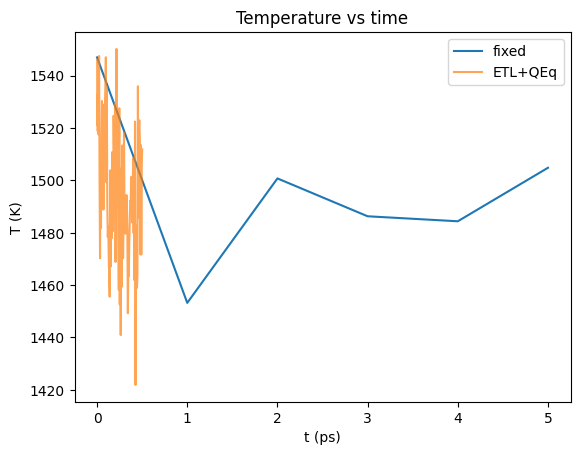

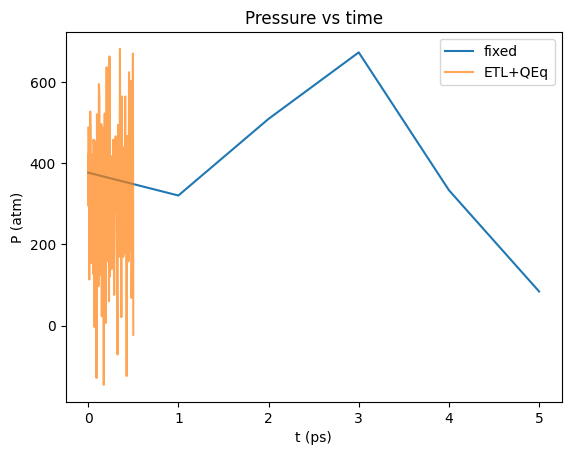

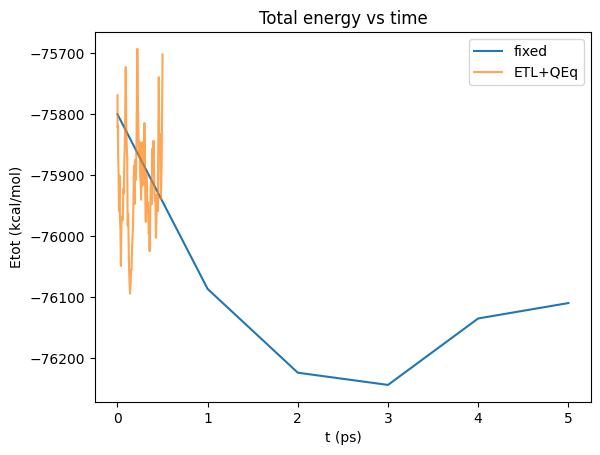

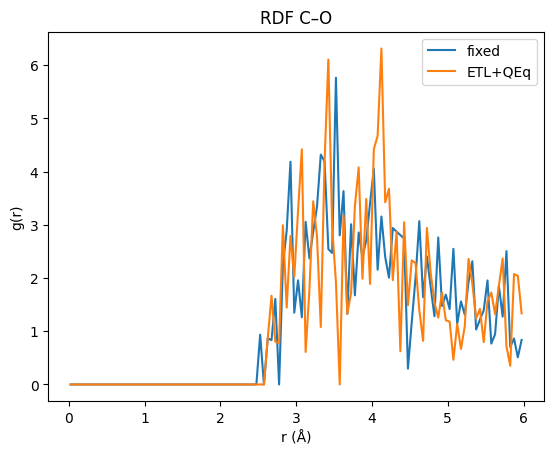

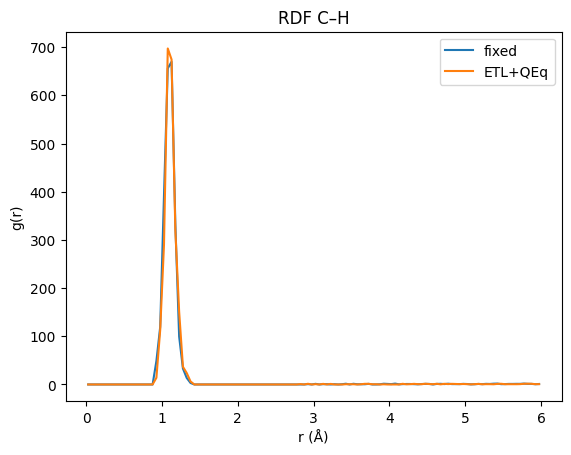

RDF L2 diffs: C–O=1.053e+00, C–H=1.170e+01


In [8]:
import json, gzip, re
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

# ---- load ETL+QEq time-series ----
etl = json.load(open("log_etl_qeq.json"))
E = pd.DataFrame({
    "t_ps": np.array(etl["etl_qeq"]["t_fs"])/1000.0,
    "dt_fs": etl["etl_qeq"]["dt_fs"],
    "tol": etl["etl_qeq"]["tol"],
    "T": etl["etl_qeq"]["temp"],
    "P": etl["etl_qeq"]["press"],
    "PE": etl["etl_qeq"]["pe"],
    "KE": etl["etl_qeq"]["ke"],
    "ETOT": etl["etl_qeq"]["etotal"],
    "QMAX": etl["etl_qeq"]["qmax"],
})

# ---- load fixed time-series from LAMMPS log ----
def parse_log_table(path):
    cols=None; rows=[]
    for line in open(path,'r',errors='ignore'):
        s=line.strip()
        if s.startswith("Step "): cols=s.split(); rows=[]; continue
        if cols and (s.startswith("Loop time of") or s.startswith("Per MPI")):
            break
        if cols:
            parts=s.split()
            if len(parts)==len(cols):
                try: rows.append([float(x) for x in parts])
                except: pass
    return pd.DataFrame(rows, columns=cols) if rows else pd.DataFrame()

F = parse_log_table("log.fixed")
# pick your fixed dt
DT = 0.1  # fs
F["t_ps"] = F["Step"]*DT/1000.0
F.rename(columns={"Temp":"T","Press":"P","Pe":"PE","Ke":"KE","TotEng":"ETOT"}, inplace=True)

# ---- summarize differences over a common time window ----
t_end = min(E["t_ps"].max(), F["t_ps"].max())
def resample(df, cols, dt_ps=0.005):
    grid = np.arange(0.0, t_end+1e-9, dt_ps)
    out = pd.DataFrame({"t_ps": grid})
    for c in cols:
        out[c] = np.interp(grid, df["t_ps"].values, df[c].values)
    return out

cols = ["T","P","ETOT"]
Er = resample(E, cols); Fr = resample(F, cols)

def summarize(a, b, name):
    diff = a-b
    print(f"{name}: "
          f"mean_rel_err={np.mean(np.abs(diff)/np.maximum(1e-12,np.abs(b))):.3%}, "
          f"RMSE={np.sqrt(np.mean(diff**2)):.3g} (units: {name})")

print("== Scalar time-series comparisons over [0, %.3f] ps ==" % t_end)
for c in cols:
    summarize(Er[c].values, Fr[c].values, c)

# ---- plots ----
plt.figure(); plt.title("Temperature vs time")
plt.plot(F["t_ps"],F["T"],label="fixed"); plt.plot(E["t_ps"],E["T"],label="ETL+QEq",alpha=0.7)
plt.xlabel("t (ps)"); plt.ylabel("T (K)"); plt.legend(); plt.show()

plt.figure(); plt.title("Pressure vs time")
plt.plot(F["t_ps"],F["P"],label="fixed"); plt.plot(E["t_ps"],E["P"],label="ETL+QEq",alpha=0.7)
plt.xlabel("t (ps)"); plt.ylabel("P (atm)"); plt.legend(); plt.show()

plt.figure(); plt.title("Total energy vs time")
plt.plot(F["t_ps"],F["ETOT"],label="fixed"); plt.plot(E["t_ps"],E["ETOT"],label="ETL+QEq",alpha=0.7)
plt.xlabel("t (ps)"); plt.ylabel("Etot (kcal/mol)"); plt.legend(); plt.show()

# ---- load one snapshot from each run and compute RDFs ----
def load_dump(fname):
    with open(fname,'r') as f:
        nat=None; box=None; ids=[]; ty=[]; pos=[]
        for line in f:
            if "ITEM: NUMBER OF ATOMS" in line:
                nat = int(next(f).strip())
            elif line.startswith("ITEM: BOX BOUNDS"):
                xlo,xhi = map(float, next(f).split()[:2])
                ylo,yhi = map(float, next(f).split()[:2])
                zlo,zhi = map(float, next(f).split()[:2])
                box = np.array([xhi-xlo, yhi-ylo, zhi-zlo])
            elif line.startswith("ITEM: ATOMS"):
                for _ in range(nat):
                    parts = next(f).split()
                    ids.append(int(parts[0])); ty.append(int(parts[1])); pos.append([float(parts[3]),float(parts[4]),float(parts[5])])
    order = np.argsort(ids)
    return np.array(ty)[order], np.array(pos)[order], box

def latest(pathpat):
    files = sorted(Path().glob(pathpat))
    return str(files[-1]) if files else None

def rdf(pos, types, A, B, box, rmax=6.0, dr=0.05):
    Aidx = np.where(np.isin(types, A))[0]
    Bidx = np.where(np.isin(types, B))[0]
    Lx,Ly,Lz = box
    edges = np.arange(0, rmax+dr, dr)
    hist = np.zeros_like(edges[:-1])
    for i in Aidx:
        d = pos[Bidx]-pos[i]
        d[:,0] -= np.rint(d[:,0]/Lx)*Lx; d[:,1] -= np.rint(d[:,1]/Ly)*Ly; d[:,2] -= np.rint(d[:,2]/Lz)*Lz
        r = np.linalg.norm(d, axis=1)
        h,_ = np.histogram(r, bins=edges); hist += h
    rho = len(Bidx)/(Lx*Ly*Lz)
    r = 0.5*(edges[1:]+edges[:-1]); shell = 4*np.pi*r*r*dr
    g = hist/(len(Aidx)*rho*shell + 1e-12)
    return r,g

f_fixed = latest("dumps_fixed/*.dump")
f_etl  = latest("dumps_etlqeq/*.dump")
if f_fixed and f_etl:
    tyF,posF,boxF = load_dump(f_fixed)
    tyE,posE,boxE = load_dump(f_etl)
    r,gCO_F = rdf(posF,tyF,[1],[3],boxF)   # C–O
    r,gCH_F = rdf(posF,tyF,[1],[2],boxF)   # C–H
    r,gCO_E = rdf(posE,tyE,[1],[3],boxE)
    r,gCH_E = rdf(posE,tyE,[1],[2],boxE)
    plt.figure(); plt.title("RDF C–O"); plt.plot(r,gCO_F,label="fixed"); plt.plot(r,gCO_E,label="ETL+QEq"); plt.legend(); plt.xlabel("r (Å)"); plt.ylabel("g(r)"); plt.show()
    plt.figure(); plt.title("RDF C–H"); plt.plot(r,gCH_F,label="fixed"); plt.plot(r,gCH_E,label="ETL+QEq"); plt.legend(); plt.xlabel("r (Å)"); plt.ylabel("g(r)"); plt.show()
    # quick scalar check:
    l2_CO = np.sqrt(np.mean((gCO_E - gCO_F)**2)); l2_CH = np.sqrt(np.mean((gCH_E - gCH_F)**2))
    print(f"RDF L2 diffs: C–O={l2_CO:.3e}, C–H={l2_CH:.3e}")
else:
    print("No dumps found to compute RDFs; check your dump/snapshot paths.")
